In [2]:
# Data handling

import pandas as pd
import numpy as np

# Train Test Split

from sklearn.model_selection import train_test_split

# Preprocessing

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Models

from sklearn.linear_model import LogisticRegression

# Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/raw/loan_data.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df = df.drop("Loan_ID", axis=1)


In [5]:
X = df.drop("Loan_Status", axis=1)

y = df["Loan_Status"]

print(X.shape)
print(y.shape)

(614, 11)
(614,)


In [6]:
categorical_features = [
    "Gender",
    "Married",
    "Dependents",
    "Education",
    "Self_Employed",
    "Property_Area"
]

numerical_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
    "Credit_History"
]

In [7]:
numerical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [8]:
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (491, 11)
Test : (123, 11)


In [11]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

In [12]:
logistic_model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [13]:
y_pred = logistic_model.predict(X_test)

y_prob = logistic_model.predict_proba(X_test)[:,1]

In [14]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Y"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Y"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Y"
)

roc_auc = roc_auc_score(
    (y_test=="Y").astype(int),
    y_prob
)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))
print("ROC AUC  :", round(roc_auc,4))

Accuracy : 0.8618
Precision: 0.84
Recall   : 0.9882
F1 Score : 0.9081
ROC AUC  : 0.8523


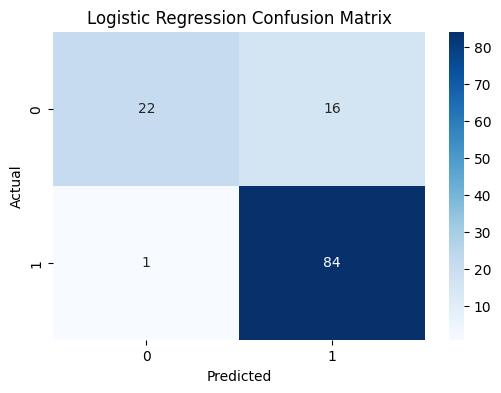

In [15]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [16]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           N       0.96      0.58      0.72        38
           Y       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [17]:
model_results = []

model_results.append({
    "Model":"Logistic Regression",
    "Accuracy":accuracy,
    "Precision":precision,
    "Recall":recall,
    "F1":f1,
    "ROC_AUC":roc_auc
})

In [19]:
from sklearn.tree import DecisionTreeClassifier

In [20]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

In [21]:
decision_tree_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [22]:
y_pred_dt = decision_tree_model.predict(
    X_test
)

y_prob_dt = decision_tree_model.predict_proba(
    X_test
)[:,1]

In [23]:
accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    pos_label="Y"
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    pos_label="Y"
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    pos_label="Y"
)

roc_auc_dt = roc_auc_score(
    (y_test=="Y").astype(int),
    y_prob_dt
)

print("Accuracy :", round(accuracy_dt,4))
print("Precision:", round(precision_dt,4))
print("Recall   :", round(recall_dt,4))
print("F1 Score :", round(f1_dt,4))
print("ROC AUC  :", round(roc_auc_dt,4))

Accuracy : 0.7561
Precision: 0.8235
Recall   : 0.8235
F1 Score : 0.8235
ROC AUC  : 0.7144


In [24]:
model_results.append({
    "Model":"Decision Tree",
    "Accuracy":accuracy_dt,
    "Precision":precision_dt,
    "Recall":recall_dt,
    "F1":f1_dt,
    "ROC_AUC":roc_auc_dt
})

In [25]:
from sklearn.ensemble import RandomForestClassifier


In [26]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

In [27]:
random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [28]:
y_pred_rf = random_forest_model.predict(X_test)

y_prob_rf = random_forest_model.predict_proba(X_test)[:,1]

In [29]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    pos_label="Y"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    pos_label="Y"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    pos_label="Y"
)

roc_auc_rf = roc_auc_score(
    (y_test=="Y").astype(int),
    y_prob_rf
)

print("Accuracy :", round(accuracy_rf,4))
print("Precision:", round(precision_rf,4))
print("Recall   :", round(recall_rf,4))
print("F1 Score :", round(f1_rf,4))
print("ROC AUC  :", round(roc_auc_rf,4))

Accuracy : 0.8211
Precision: 0.8462
Recall   : 0.9059
F1 Score : 0.875
ROC AUC  : 0.7808


In [30]:
model_results.append({
    "Model":"Random Forest",
    "Accuracy":accuracy_rf,
    "Precision":precision_rf,
    "Recall":recall_rf,
    "F1":f1_rf,
    "ROC_AUC":roc_auc_rf
})

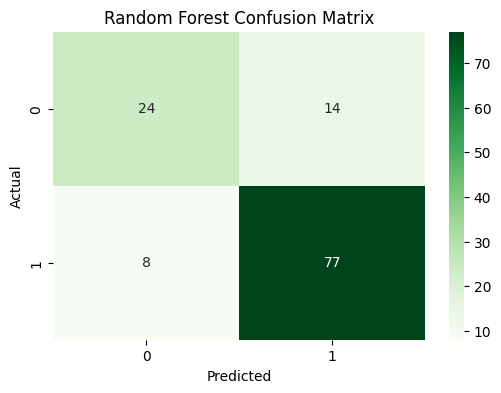

In [31]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [32]:
from xgboost import XGBClassifier

In [33]:
y_train_xgb = y_train.map({"N":0,"Y":1})

y_test_xgb = y_test.map({"N":0,"Y":1})

In [34]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=100,
                max_depth=3,
                learning_rate=0.1,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [35]:
xgb_model.fit(
    X_train,
    y_train_xgb
)

print("XGBoost Trained Successfully")

XGBoost Trained Successfully


In [36]:
y_pred_xgb = xgb_model.predict(X_test)

y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

In [37]:
accuracy_xgb = accuracy_score(
    y_test_xgb,
    y_pred_xgb
)

precision_xgb = precision_score(
    y_test_xgb,
    y_pred_xgb
)

recall_xgb = recall_score(
    y_test_xgb,
    y_pred_xgb
)

f1_xgb = f1_score(
    y_test_xgb,
    y_pred_xgb
)

roc_auc_xgb = roc_auc_score(
    y_test_xgb,
    y_prob_xgb
)

print("Accuracy :", round(accuracy_xgb,4))
print("Precision:", round(precision_xgb,4))
print("Recall   :", round(recall_xgb,4))
print("F1 Score :", round(f1_xgb,4))
print("ROC AUC  :", round(roc_auc_xgb,4))

Accuracy : 0.8211
Precision: 0.8316
Recall   : 0.9294
F1 Score : 0.8778
ROC AUC  : 0.7563


In [38]:
model_results.append({
    "Model":"XGBoost",
    "Accuracy":accuracy_xgb,
    "Precision":precision_xgb,
    "Recall":recall_xgb,
    "F1":f1_xgb,
    "ROC_AUC":roc_auc_xgb
})

In [39]:
results_df = pd.DataFrame(model_results)

results_df.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108,0.852322
2,Random Forest,0.821138,0.846154,0.905882,0.875000,0.780805
3,XGBoost,0.821138,0.831579,0.929412,0.877778,0.756347
1,Decision Tree,0.756098,0.823529,0.823529,0.823529,0.714396


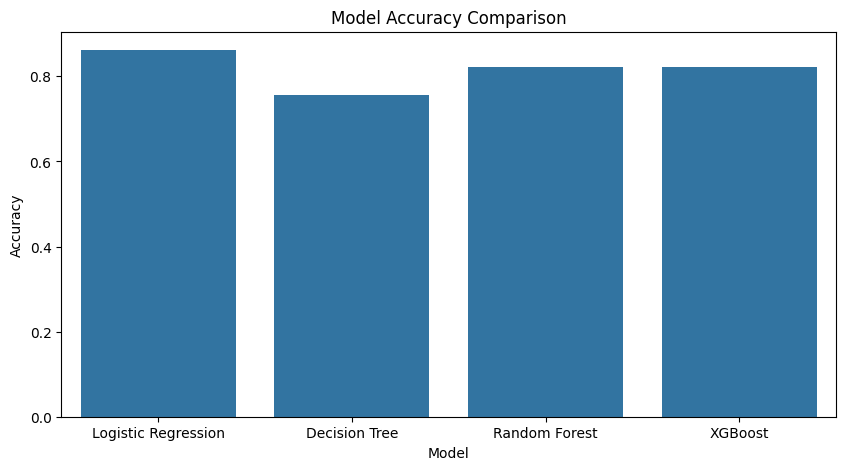

In [40]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results_df
)

plt.title("Model Accuracy Comparison")

plt.show()

In [41]:
import joblib

joblib.dump(
    logistic_model,
    "../models/loan_model.pkl"
)

print("Best Model Saved Successfully")

Best Model Saved Successfully


In [42]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)

['num__ApplicantIncome' 'num__CoapplicantIncome' 'num__LoanAmount'
 'num__Loan_Amount_Term' 'num__Credit_History' 'cat__Gender_Female'
 'cat__Gender_Male' 'cat__Married_No' 'cat__Married_Yes'
 'cat__Dependents_0' 'cat__Dependents_1' 'cat__Dependents_2'
 'cat__Dependents_3+' 'cat__Education_Graduate'
 'cat__Education_Not Graduate' 'cat__Self_Employed_No'
 'cat__Self_Employed_Yes' 'cat__Property_Area_Rural'
 'cat__Property_Area_Semiurban' 'cat__Property_Area_Urban']


In [43]:
coefficients = logistic_model.named_steps[
    "classifier"
].coef_[0]

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(10)

,Feature,Importance
4,num__Credit_History,1.247119
18,cat__Property_Area_Semiurban,0.463860
11,cat__Dependents_2,0.317990
8,cat__Married_Yes,0.276226
13,cat__Education_Graduate,0.192954
12,cat__Dependents_3+,0.135623
15,cat__Self_Employed_No,0.108466
5,cat__Gender_Female,0.091072
0,num__ApplicantIncome,0.011757
3,num__Loan_Amount_Term,-0.018088


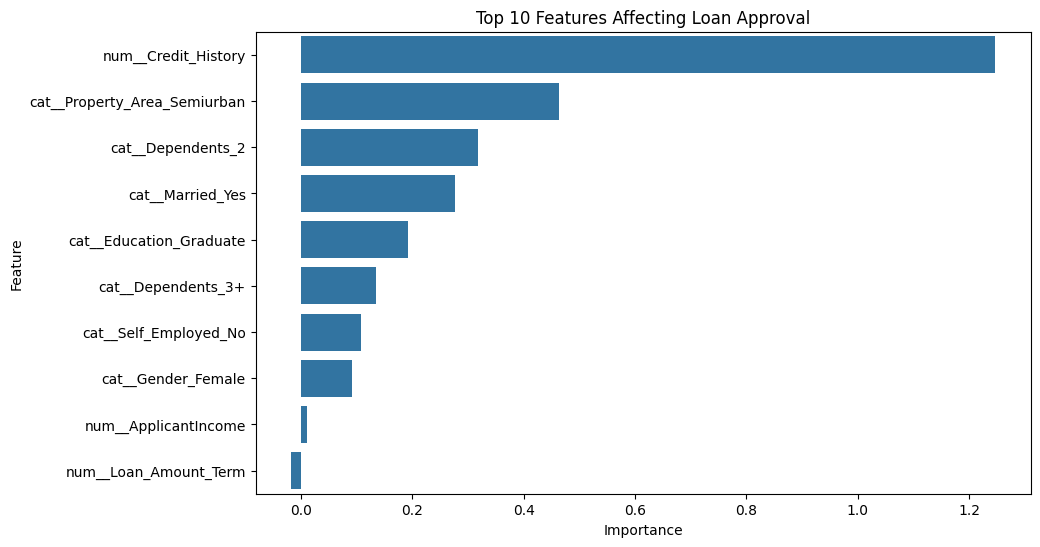

In [44]:
top_features = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title(
    "Top 10 Features Affecting Loan Approval"
)

plt.show()

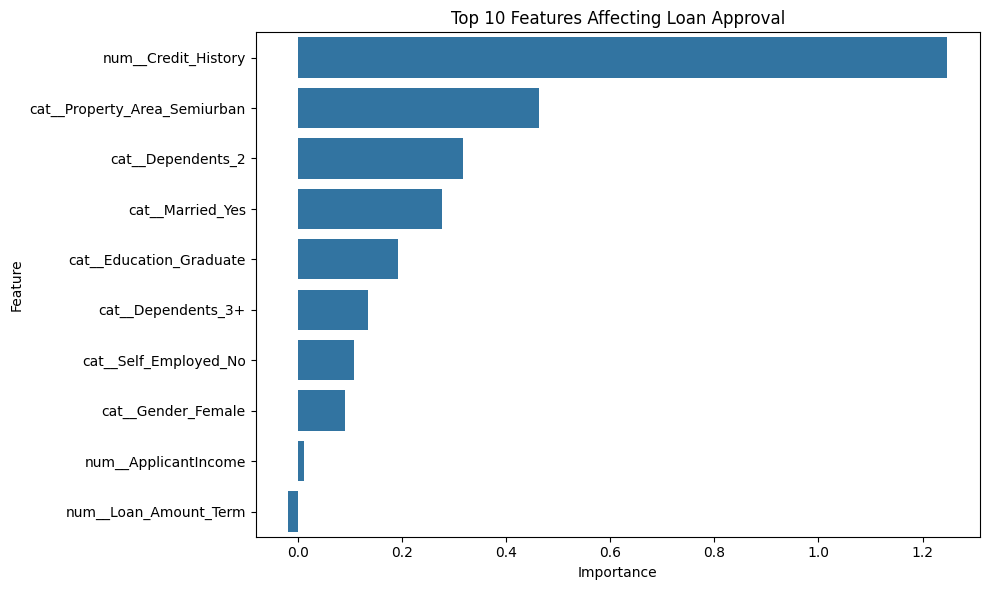

In [45]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=top_features
)

plt.title(
    "Top 10 Features Affecting Loan Approval"
)

plt.tight_layout()

plt.savefig(
    "../reports/figures/feature_importance.png"
)

plt.show()

In [46]:
importance_df.head(10)

,Feature,Importance
4,num__Credit_History,1.247119
18,cat__Property_Area_Semiurban,0.463860
11,cat__Dependents_2,0.317990
8,cat__Married_Yes,0.276226
13,cat__Education_Graduate,0.192954
12,cat__Dependents_3+,0.135623
15,cat__Self_Employed_No,0.108466
5,cat__Gender_Female,0.091072
0,num__ApplicantIncome,0.011757
3,num__Loan_Amount_Term,-0.018088


In [47]:
import joblib

joblib.dump(
    logistic_model,
    "../models/loan_model.pkl"
)

print("Loan Model Saved Successfully")

Loan Model Saved Successfully
